# Analyse exploratoire

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import des différents datasets

hotel_booking = pd.read_csv("../data/raw/hotel_bookings.csv")

business = pd.read_csv("../data/raw/business.csv")
economy = pd.read_csv("../data/raw/economy.csv")
flight_clean = pd.read_csv("../data/raw/Clean_Dataset.csv")

In [3]:
print("Hotel :", hotel_booking.shape)
print("Business :", business.shape)
print("Economy :", economy.shape)
print("Flight Clean :", flight_clean.shape)

Hotel : (119390, 32)
Business : (93487, 11)
Economy : (206774, 11)
Flight Clean : (300153, 12)


## Analyse du dataset hôtel

Le dataset contient 119 390 réservations.

### Compréhension globale

In [4]:
hotel_booking.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
hotel_booking.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

#### Interprétation

Le dataset hôtel contient 119 390 réservations réparties sur 32 variables.

Les données sont composées :
- de variables numériques (int64, float64),
- de variables catégorielles (object/str).

La majorité des colonnes sont complètes, ce qui est un point positif pour la suite de l'analyse et la modélisation.

### Valeurs manquantes

In [6]:
#valeurs manquantes

hotel_booking.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
missing = hotel_booking.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

company     112593
agent        16340
country        488
children         4
dtype: int64

### Interprétation des valeurs manquantes

Quatre colonnes présentent des valeurs manquantes.

- `company` possède 112 593 valeurs manquantes sur 119 390 observations. Cette colonne est presque vide et pourrait être supprimée lors du prétraitement.
- `agent` contient 16 340 valeurs manquantes. Il faudra déterminer si ces valeurs doivent être remplacées ou si la variable doit être conservée telle quelle.
- `country` présente seulement 488 valeurs manquantes, soit une proportion très faible du dataset.
- `children` ne contient que 4 valeurs manquantes, ce qui pourra être facilement corrigé.

Globalement, le dataset présente peu de valeurs manquantes, à l'exception des colonnes `company` et `agent`.

Observation :
La variable `company` contient plus de 94 % de valeurs manquantes et pourrait être supprimée lors du prétraitement.

### Doublons 

In [8]:
hotel_booking.duplicated().sum()

np.int64(31994)

In [9]:
hotel_booking[hotel_booking.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


#### Interprétation

Le dataset contient 31 994 lignes identifiées comme des doublons complets, soit environ 26,8 % des observations.

Cette proportion est relativement élevée. Une analyse complémentaire sera nécessaire lors de la phase de prétraitement afin de déterminer si ces doublons correspondent à des réservations réellement dupliquées ou à des réservations distinctes partageant exactement les mêmes caractéristiques.

À ce stade, aucune suppression de doublons n'est effectuée.

### Statistiques descriptives

In [10]:
hotel_booking.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


#### Interprétation

L'analyse des statistiques descriptives permet d'obtenir une première vision des caractéristiques principales du dataset.

##### Taux d'annulation

La variable `is_canceled` présente une moyenne de 0,37, ce qui signifie qu'environ 37 % des réservations ont été annulées.

Ce taux relativement élevé montre que les annulations représentent un enjeu important pour les établissements hôteliers.

##### Délai de réservation (Lead Time)

Les clients réservent en moyenne 104 jours avant leur arrivée, avec une médiane de 69 jours.

L'écart entre la moyenne et la médiane suggère une distribution asymétrique, avec certaines réservations effectuées très longtemps à l'avance. Le délai maximal observé atteint 737 jours.

##### Durée des séjours

La plupart des clients séjournent peu de temps à l'hôtel. Toutefois, certaines réservations atteignent jusqu'à 19 nuits en week-end et 50 nuits en semaine, soit un total potentiel de 69 nuits.

Ces valeurs pourraient correspondre à des séjours longue durée ou à des observations atypiques.

##### Composition des réservations

Les réservations concernent principalement deux adultes, comme l'indique la médiane de la variable `adults`.

Cependant, certaines réservations comptent jusqu'à 55 adultes, ce qui constitue une valeur inhabituelle qui devra être examinée plus en détail.

##### Prix journalier moyen (ADR)

Le prix journalier moyen est d'environ 102 €, avec une médiane de 95 €.

On observe néanmoins des valeurs extrêmes, allant de -6,38 € à 5 400 €. Ces observations suggèrent la présence de valeurs aberrantes qui devront être étudiées lors de la phase de prétraitement.

### Visualisations

#### Répartition des annulations

/var/folders/g6/_fb35h6n4r7gskyw19rk12900000gn/T/ipykernel_2249/2022637946.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


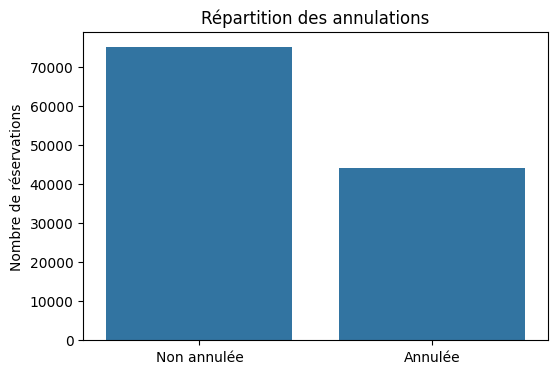

In [11]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=hotel_booking,
    x="is_canceled"
)

ax.set_xticklabels([
    "Non annulée",
    "Annulée"
])

plt.title("Répartition des annulations")
plt.xlabel("")
plt.ylabel("Nombre de réservations")

plt.show()

La majorité des réservations n'ont pas été annulées. On observe environ 75 000 réservations maintenues contre environ 44 000 réservations annulées.

Les annulations représentent néanmoins une part importante du dataset avec près de 37 % des réservations.

Cette proportion confirme l'intérêt d'étudier les facteurs influençant les annulations et de développer un modèle prédictif capable d'anticiper ce phénomène.

#### Type d'hôtel VS Annulation

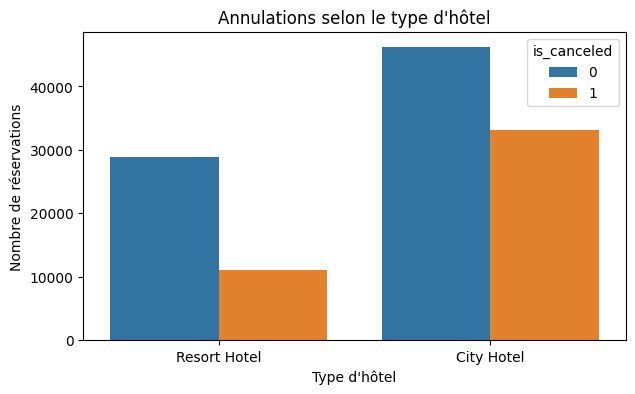

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


In [12]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=hotel_booking,
    x="hotel",
    hue="is_canceled"
)

plt.title("Annulations selon le type d'hôtel")
plt.xlabel("Type d'hôtel")
plt.ylabel("Nombre de réservations")

plt.show()

pd.crosstab(
    hotel_booking["hotel"],
    hotel_booking["is_canceled"],
    normalize="index"
) * 100

L'analyse des proportions confirme que les City Hotels présentent un taux d'annulation plus élevé que les Resort Hotels.

Environ 41,7 % des réservations effectuées dans les City Hotels sont annulées, contre 27,8 % pour les Resort Hotels.

Le type d'hôtel semble donc être une variable fortement liée au risque d'annulation et pourrait constituer un facteur important pour la modélisation prédictive.

#### Lead Time VS Annulation

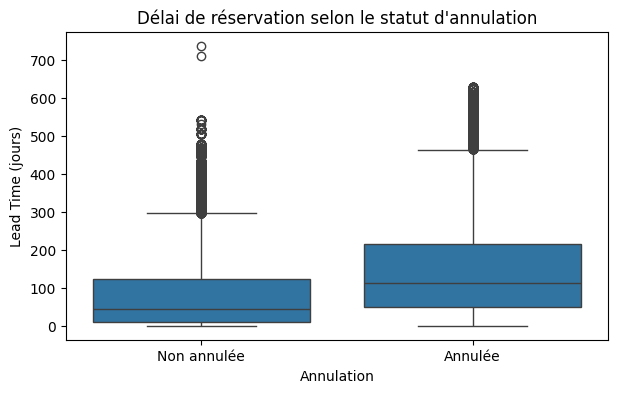

In [13]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=hotel_booking,
    x="is_canceled",
    y="lead_time"
)

plt.title("Délai de réservation selon le statut d'annulation")
plt.xlabel("Annulation")
plt.ylabel("Lead Time (jours)")

plt.xticks([0,1], ["Non annulée","Annulée"])

plt.show()

Le délai de réservation semble fortement lié au comportement d'annulation.

Les réservations annulées présentent un délai de réservation médian nettement supérieur à celui des réservations maintenues.

Les clients qui réservent plusieurs mois à l'avance semblent davantage susceptibles d'annuler leur séjour. Cette observation est cohérente avec le fait qu'un horizon temporel plus long augmente la probabilité de changement de plans.

Le lead time apparaît ainsi comme une variable potentiellement importante pour prédire les annulations.

#### ADR VS Annulation

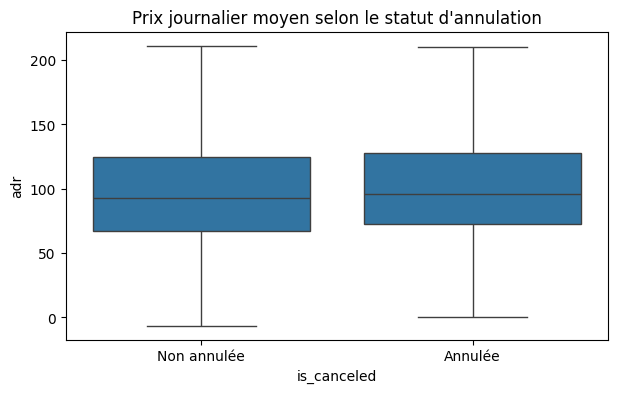

In [14]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=hotel_booking,
    x="is_canceled",
    y="adr",
    showfliers=False
)

plt.xticks([0,1], ["Non annulée", "Annulée"])

plt.title("Prix journalier moyen selon le statut d'annulation")
plt.show()

Après suppression visuelle des valeurs aberrantes, les distributions du prix journalier moyen (ADR) apparaissent relativement similaires entre les réservations annulées et non annulées.

Les réservations annulées présentent une médiane légèrement supérieure, mais les deux groupes se recouvrent largement.

Cette observation suggère que le prix pourrait avoir une influence sur les annulations, mais que son impact semble moins marqué que celui du délai de réservation ou du type d'hôtel.

### Conclusion de l'analyse exploratoire du dataset hôtel

L'analyse exploratoire du dataset hôtel a permis d'identifier plusieurs facteurs potentiellement liés aux annulations.

Le type d'hôtel et le délai de réservation apparaissent comme les variables les plus influentes. Les City Hotels présentent un taux d'annulation plus élevé que les Resort Hotels, tandis que les réservations effectuées longtemps à l'avance sont davantage susceptibles d'être annulées.

Le prix journalier moyen semble également jouer un rôle, mais son influence paraît moins marquée.

Enfin, plusieurs valeurs aberrantes et données manquantes ont été identifiées et devront être traitées lors de la phase de prétraitement.

## Analyse des dataset des vols

In [15]:
business.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [16]:
economy.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [17]:
flight_clean.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [18]:
business.info()

<class 'pandas.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        93487 non-null  str  
 1   airline     93487 non-null  str  
 2   ch_code     93487 non-null  str  
 3   num_code    93487 non-null  int64
 4   dep_time    93487 non-null  str  
 5   from        93487 non-null  str  
 6   time_taken  93487 non-null  str  
 7   stop        93487 non-null  str  
 8   arr_time    93487 non-null  str  
 9   to          93487 non-null  str  
 10  price       93487 non-null  str  
dtypes: int64(1), str(10)
memory usage: 15.6 MB


In [19]:
economy.info()

<class 'pandas.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   date        206774 non-null  str  
 1   airline     206774 non-null  str  
 2   ch_code     206774 non-null  str  
 3   num_code    206774 non-null  int64
 4   dep_time    206774 non-null  str  
 5   from        206774 non-null  str  
 6   time_taken  206774 non-null  str  
 7   stop        206774 non-null  str  
 8   arr_time    206774 non-null  str  
 9   to          206774 non-null  str  
 10  price       206774 non-null  str  
dtypes: int64(1), str(10)
memory usage: 33.8 MB


In [20]:
flight_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


Les datasets Business et Economy possèdent chacun 11 variables décrivant les caractéristiques des vols (compagnie aérienne, ville de départ, ville d’arrivée, durée, nombre d’escales, prix, etc.).

La structure des deux datasets est identique, la principale différence étant la classe de voyage représentée. Aucun problème de valeurs manquantes n'est observé.

#### Flight Clean
Le dataset Clean_Dataset constitue une version consolidée et préparée pour l'analyse. Il regroupe 300 153 vols et contient 12 variables.

Contrairement aux datasets Business et Economy, plusieurs variables ont déjà été transformées sous un format exploitable pour l'analyse statistique et la modélisation, notamment la durée du vol (duration) et le prix (price).

Aucune valeur manquante n'a été détectée. La variable "Unnamed: 0" correspond à un ancien index issu de l'exportation du fichier CSV. Cette colonne n'apporte aucune information utile à l'analyse et pourra être supprimée lors du prétraitement.

In [21]:
flight_clean.isnull().sum()
flight_clean.duplicated().sum()
flight_clean.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


L'analyse statistique met en évidence une forte dispersion des prix des billets. La médiane (7 425) est nettement inférieure à la moyenne (20 890), ce qui suggère la présence de vols particulièrement coûteux influençant fortement la distribution.

Les durées de vol varient également de manière importante, allant d'environ 50 minutes à près de 50 heures selon les itinéraires et le nombre d'escales.

Enfin, les réservations sont effectuées entre 1 et 49 jours avant le départ, avec une moyenne d'environ 26 jours.

In [22]:
# Valeurs manquantes

flight_clean.duplicated().sum()

np.int64(0)

In [23]:
flight_clean.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Aucune valeur manquante n'a été détectée dans le dataset. Toutes les variables sont complètes et directement exploitables pour l'analyse et la modélisation.

Aucun doublon n'a été identifié dans le dataset. Chaque observation correspond donc à un vol unique.

### Visualisations

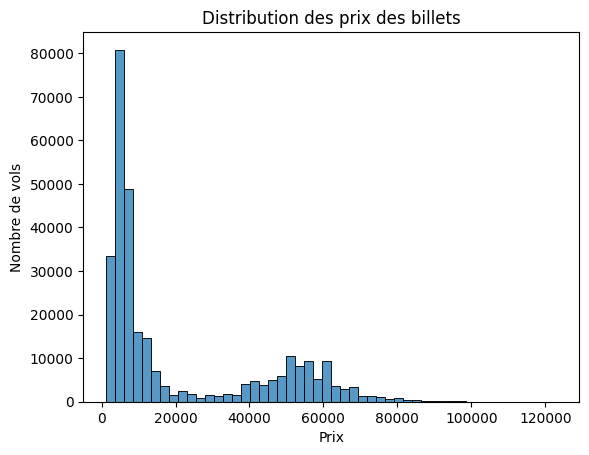

In [24]:
# Distribution des prix
sns.histplot(
    data=flight_clean,
    x="price",
    bins=50
)

plt.title("Distribution des prix des billets")
plt.xlabel("Prix")
plt.ylabel("Nombre de vols")
plt.show()

La distribution des prix n'est pas uniforme et présente une forte asymétrie. Deux groupes de prix apparaissent clairement : un premier correspondant aux billets les moins chers et un second regroupant les billets les plus coûteux.

Cette répartition suggère que certaines variables, notamment la classe du billet (Economy ou Business), influencent fortement le prix et devront être prises en compte lors de la modélisation.

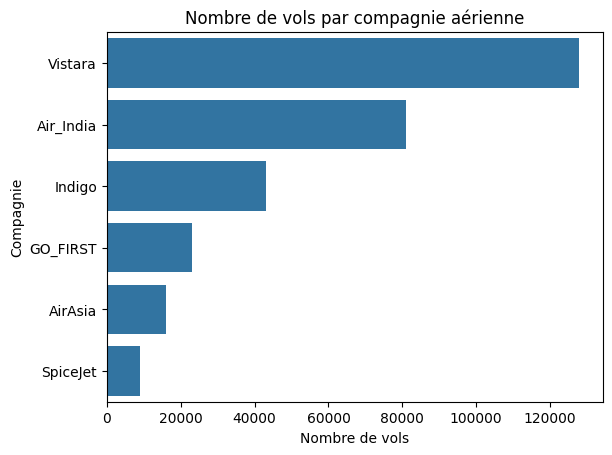

In [25]:
# Répartitions des compagnies 
sns.countplot(
    data=flight_clean,
    y="airline",
    order=flight_clean["airline"].value_counts().index
)

plt.title("Nombre de vols par compagnie aérienne")
plt.xlabel("Nombre de vols")
plt.ylabel("Compagnie")
plt.show()

La répartition des vols n'est pas homogène entre les différentes compagnies aériennes.

Vistara est la compagnie la plus représentée dans le dataset, suivie par Air India. À l'inverse, SpiceJet, AirAsia et GO_FIRST disposent d'un nombre de vols beaucoup plus faible.

Cette répartition déséquilibrée devra être prise en compte lors de la modélisation, certaines compagnies étant davantage représentées que d'autres dans les données.

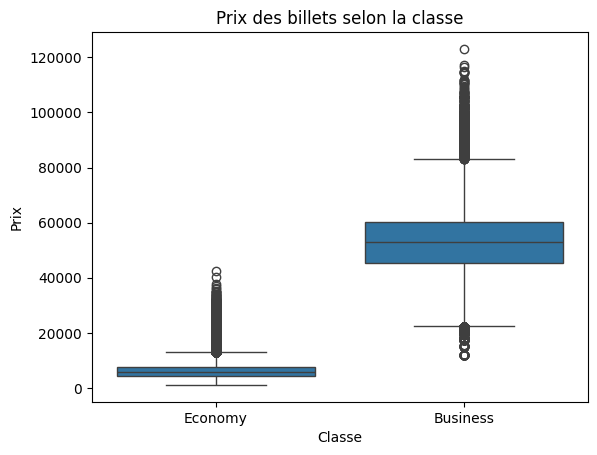

In [26]:
# Classe VS Prix
sns.boxplot(
    data=flight_clean,
    x="class",
    y="price"
)

plt.title("Prix des billets selon la classe")
plt.xlabel("Classe")
plt.ylabel("Prix")
plt.show()

Le prix des billets varie fortement selon la classe choisie.

Les billets en classe Business présentent des prix nettement supérieurs à ceux de la classe Economy, avec une médiane proche de 50 000 contre environ 6 000 pour les billets Economy. De plus, les prix en classe Business sont plus dispersés, ce qui traduit une plus grande variabilité des tarifs.

La variable **class** apparaît donc comme l'un des facteurs les plus influents pour expliquer le prix d'un billet et devra être conservée pour la modélisation.

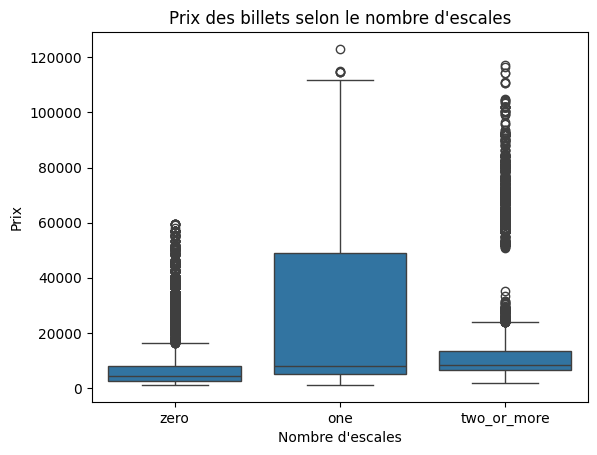

In [27]:
# Escales VS Prix 
sns.boxplot(
    data=flight_clean,
    x="stops",
    y="price"
)

plt.title("Prix des billets selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix")
plt.show()

In [28]:
flight_clean.groupby("stops")["price"].median()

stops
one            7959.0
two_or_more    8307.0
zero           4499.0
Name: price, dtype: float64

In [29]:
flight_clean.groupby("stops")["price"].mean()

stops
one            22900.992482
two_or_more    14113.450775
zero            9375.938535
Name: price, dtype: float64

Les vols sans escale sont globalement les moins chers (médiane : 4 499). Les vols avec une ou plusieurs escales présentent des prix plus élevés. Les vols avec une escale affichent la moyenne la plus importante (22 901), ce qui traduit la présence de nombreux billets à prix très élevés, probablement liés aux vols en classe Business ou à certaines compagnies.

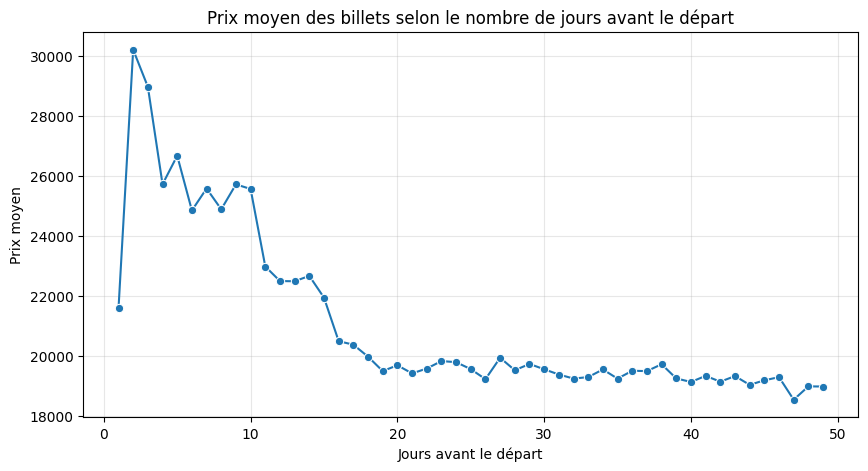

In [32]:
# Jours restants avant départ VS prix
prix_jours = flight_clean.groupby("days_left")["price"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=prix_jours,
    x="days_left",
    y="price",
    marker="o"
)

plt.title("Prix moyen des billets selon le nombre de jours avant le départ")
plt.xlabel("Jours avant le départ")
plt.ylabel("Prix moyen")
plt.grid(alpha=0.3)

plt.show()

Les prix moyens des billets sont plus élevés lorsque la réservation est effectuée peu de temps avant le départ. À l'inverse, réserver plusieurs semaines à l'avance est associé à des tarifs plus faibles et plus stables. Cette tendance est cohérente avec les stratégies de tarification dynamique des compagnies aériennes.

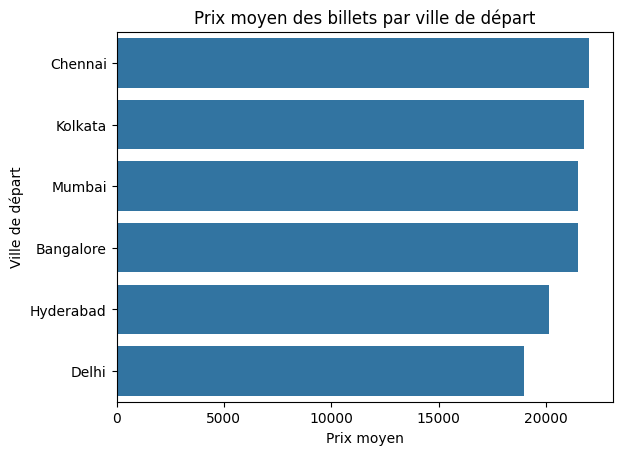

In [33]:
# Prix moyen par ville de départ 
prix_depart = (
    flight_clean
    .groupby("source_city")["price"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=prix_depart.values,
    y=prix_depart.index
)

plt.title("Prix moyen des billets par ville de départ")
plt.xlabel("Prix moyen")
plt.ylabel("Ville de départ")
plt.show()

Les prix moyens des billets varient selon la ville de départ. Chennai présente le prix moyen le plus élevé, tandis que Delhi affiche le prix moyen le plus faible. Les écarts restent toutefois relativement modérés, ce qui suggère que la ville de départ influence le prix, sans être le facteur principal.

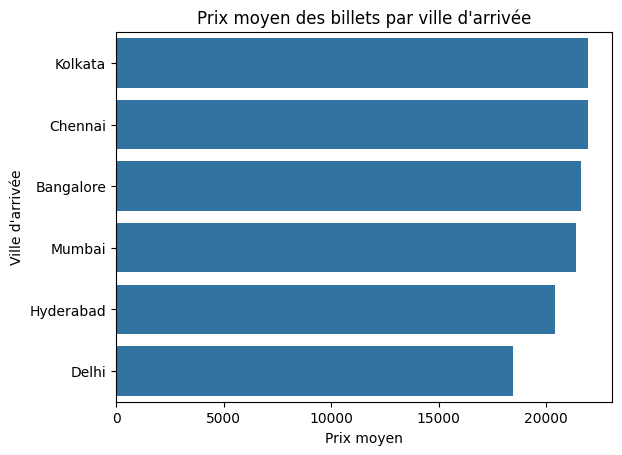

In [34]:
# Prix moyen par ville d'arrivée 
prix_arrivee = (
    flight_clean
    .groupby("destination_city")["price"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=prix_arrivee.values,
    y=prix_arrivee.index
)

plt.title("Prix moyen des billets par ville d'arrivée")
plt.xlabel("Prix moyen")
plt.ylabel("Ville d'arrivée")
plt.show()

Les prix moyens varient légèrement selon la ville d'arrivée. Kolkata présente le prix moyen le plus élevé, tandis que Delhi affiche le plus faible. Les différences restent toutefois modérées, ce qui indique que la destination influence le prix sans constituer le principal facteur explicatif.